# **Phase 2 — Engineer & Transform Features**
***Feature Engineering***

we will create new columns, convert
categories to numbers, and rescale features.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
CLEANED_PATH = "Data/Cleaned/ames_cleaned.csv"
df = pd.read_csv(CLEANED_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Loaded: 2,929 rows x 78 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0



# **Task 1:**
---


# **One-hot encode at least 2 categorical columns using pd.get_dummies()**


---


Encoding `MS Zoning` and `Neighborhood` as binary columns so the model
treats each category independently without implying any numeric order.


In [14]:
# Source: Week 4, Day 16 — One-Hot Encoding with pd.get_dummies
def encode_onehot(df, columns):
    df = pd.get_dummies(df, columns=columns, prefix=columns, drop_first=True)
    print(f'Shape after one-hot encoding: {df.shape}')
    return df
df = encode_onehot(df, ['MS Zoning', 'Neighborhood'])

Shape after one-hot encoding: (2929, 109)


#**Task 2:**

---




#**Ordinal encode 1 ordered column (e.g., quality: low → high)**


---


`Kitchen Qual` has a clear order (Poor → Excellent). Preserving this rank
helps models understand that higher quality means higher value.

In [15]:

# Source: Week 4, Day 16 — Nominal vs Ordinal Categories
def encode_ordinal(df):
    # Kitchen Qual has meaningful order: Poor < Fair < Typical < Good < Excellent
    quality_order = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    df['Kitchen Qual'] = df['Kitchen Qual'].map(quality_order)
    print(f'Kitchen Qual encoded — unique values: {sorted(df["Kitchen Qual"].unique())}')
    return df
df = encode_ordinal(df)

Kitchen Qual encoded — unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


# **Task 3:**
---




#**Scale at least 2 numerical columns using StandardScaler**


---


Without scaling, large-range features dominate distance-based models
simply because of their numeric magnitude.

In [16]:
# Source: Week 4, Day 17 — Standardization (Z-Score Scaling)
def scale_features(df, columns):
    scaler = StandardScaler()
    df[columns] = scaler.fit_transform(df[columns])
    print(f'Scaled columns: {columns}')
    print(df[columns].agg(['mean', 'std']).round(2))
    return df

df = scale_features(df, ['Gr Liv Area', 'Lot Area'])

Scaled columns: ['Gr Liv Area', 'Lot Area']
      Gr Liv Area  Lot Area
mean         -0.0       0.0
std           1.0       1.0



# **Task 4:**
---



# **-Create 2 domain features: a meaningful ratio (e.g., price_per_sqft) and one more of your choice.**
# **-We use safe division to avoid dividing by zero**


---



Buyers compare cost per unit area, not absolute price.
`bath_per_bed` measures the comfort level of the house layout.





In [17]:
# Source: Week 5, Day 21 — Ratio Features with Safe Division
def create_domain_features(df, df_original):
    # Use original unscaled columns for meaningful ratios
    # Ratio 1: price per square foot
    df['price_per_sqft'] = df_original['SalePrice'] / \
                           df_original['Gr Liv Area'].replace({0: np.nan})
    df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())

    # Ratio 2: total bathrooms per bedroom — comfort ratio
    df['bath_per_bed'] = (df_original['Full Bath'] + df_original['Half Bath'] * 0.5) / \
                          df_original['Bedroom AbvGr'].replace({0: np.nan})
    df['bath_per_bed'] = df['bath_per_bed'].fillna(df['bath_per_bed'].median())
    print(f'price_per_sqft — mean: ${df["price_per_sqft"].mean():.1f}')
    print(f'bath_per_bed   — mean: {df["bath_per_bed"].mean():.2f}')
    print(f'Shape: {df.shape}')
    return df
# Load original for reference
df_original = pd.read_csv(CLEANED_PATH)
df = create_domain_features(df, df_original)

price_per_sqft — mean: $121.0
bath_per_bed   — mean: 0.65
Shape: (2929, 111)


# **Task 5:**

---

# **Create 1 interaction feature: multiply two columns that logically go together (e.g., quality × area)**

---

A bigger AND better-quality house is worth significantly more —
neither column alone captures this joint effect.

In [18]:
# Source: Week 5, Day 22 — Multiplicative Interactions
def create_interaction_features(df, df_original):
    # Quality x Area — bigger AND better house should be worth much more
    df['qual_x_area'] = df_original['Overall Qual'] * df_original['Gr Liv Area']
    print(f'qual_x_area — mean: {df["qual_x_area"].mean():.1f}')
    print(f'Shape: {df.shape}')
    return df


df = create_interaction_features(df, df_original)

qual_x_area — mean: 9548.1
Shape: (2929, 112)


# **Task 6:**

---

# **Log-transform 1 skewed column using np.log1p() — show the histogram before and after**


---
`Lot Area` has a heavy right tail. log1p compresses extreme values
and makes the distribution more symmetric for linear models.



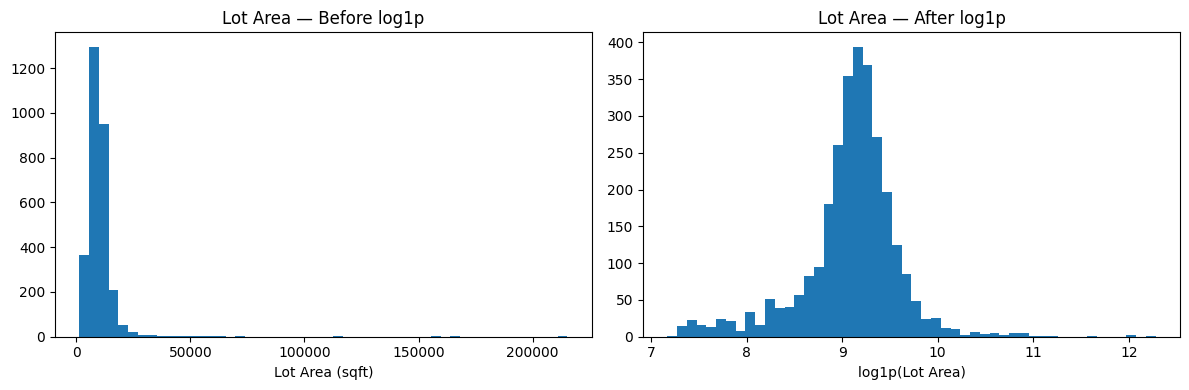

Shape: (2929, 113)


In [19]:

# Source: Week 4, Day 19 — Log Transform with np.log1p
def log_transform(df, df_original):
    # LotArea is heavily right-skewed — log1p compresses the long tail
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_original['Lot Area'], bins=50)
    axes[0].set_title('Lot Area — Before log1p')
    axes[0].set_xlabel('Lot Area (sqft)')
    df['Lot Area log1p'] = np.log1p(df_original['Lot Area'])
    axes[1].hist(df['Lot Area log1p'], bins=50)
    axes[1].set_title('Lot Area — After log1p')
    axes[1].set_xlabel('log1p(Lot Area)')
    plt.tight_layout()
    plt.show()
    print(f'Shape: {df.shape}')
    return df
df = log_transform(df, df_original)

# **Task 7:**

---

Bin 1 column into meaningful groups (e.g., age groups: New, Recent, Old)

---
Houses from different eras have different characteristics —
pre-war homes behave differently from new construction.


In [20]:
# Source: Week 4, Day 18 — Domain-Driven Binning with pd.cut
def bin_features(df, df_original):
    # Bin Year Built into meaningful groups
    bin_edges  = [0, 1940, 1970, 1990, 2010, 2030]
    bin_labels = ['Very Old', 'Old', 'Mid', 'Recent', 'New']

    df['House Age Group'] = pd.cut(
        df_original['Year Built'],
        bins=bin_edges,
        labels=bin_labels,
        right=False
    )
    print('House Age Group distribution:')
    print(df['House Age Group'].value_counts().sort_index())
    print(f'Shape: {df.shape}')
    return df
df = bin_features(df, df_original)

House Age Group distribution:
House Age Group
Very Old     481
Old          848
Mid          484
Recent      1113
New            3
Name: count, dtype: int64
Shape: (2929, 114)


# **Task 8:**

---

# **Remove redundant features: find highly correlated pairs (r > 0.95) and drop one**

---
Redundant features add noise without adding information
and can destabilize model coefficients.


In [21]:
# Source: Week 5, Day 24 — Redundant Feature Removal
def drop_correlated_features(df, threshold=0.95):
    # Select numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

    df = df.drop(columns=to_drop)
    print(f'Dropped {len(to_drop)} correlated columns: {to_drop}')
    print(f'Shape: {df.shape}')
    return df
df = drop_correlated_features(df, threshold=0.95)

Dropped 1 correlated columns: ['Yr Sold']
Shape: (2929, 113)


# **Save final engineered DataFrame**

In [22]:
FEATURES_PATH = 'ames_features.csv'
df.to_csv(FEATURES_PATH, index=False)
print(f'Saved to: {FEATURES_PATH}')
print(f'Final shape: {df.shape}')

Saved to: ames_features.csv
Final shape: (2929, 113)
